In [ ]:
!pip install transformers torch scikit-learn

### Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import json
import re

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load GoEmotion Model

In [3]:
MODEL_NAME = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

id2label = model.config.id2label
labels = [id2label[i] for i in range(len(id2label))]

# Emotion mappings
POSITIVE_EMOTIONS = {
    "admiration", "amusement", "approval", "caring", "desire", "excitement",
    "gratitude", "joy", "love", "optimism", "pride", "relief"
}
NEGATIVE_EMOTIONS = {
    "anger", "annoyance", "disappointment", "disapproval", "disgust",
    "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"
}

# Intensity boosters
INTENSITY_BOOSTERS = {
    'very', 'really', 'extremely', 'absolutely', 'completely',
    'totally', 'so', 'super', 'highly', 'utterly', 'deeply', 'too'
}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

### Load PyGENTs lexicons

In [4]:
def load_pygents_lexicons():

    with open('/content/drive/MyDrive/My Research/Social_Graph_Mining/Sentiment/positive.txt', 'r') as f:
        positive_words = set([line.strip().lower() for line in f if line.strip()])

    with open('/content/drive/MyDrive/My Research/Social_Graph_Mining/Sentiment/negative.txt', 'r') as f:
        negative_words = set([line.strip().lower() for line in f if line.strip()])

    print(f"Loaded {len(positive_words)} positive words and {len(negative_words)} negative words")
    return positive_words, negative_words

positive_lexicon, negative_lexicon = load_pygents_lexicons()

Loaded 3850 positive words and 8201 negative words


###  Lexicon-Based Detection with Intensity

In [5]:
def lexicon_based_analysis(text, positive_lexicon, negative_lexicon):

    text_lower = text.lower()
    words = re.findall(r'\b\w+\b', text_lower)

    positive_score = 0
    negative_score = 0
    intensity_multiplier = 1.0
    detected_words = []

    # Check for intensity boosters and emotional words
    for i, word in enumerate(words):
        if word in INTENSITY_BOOSTERS:
            intensity_multiplier = 2.0  # Boost next emotional word
            continue

        if word in positive_lexicon:
            score = 1.0 * intensity_multiplier
            positive_score += score
            detected_words.append(('positive', word, score))
            intensity_multiplier = 1.0  # Reset multiplier

        elif word in negative_lexicon:
            score = 1.0 * intensity_multiplier
            negative_score += score
            detected_words.append(('negative', word, score))
            intensity_multiplier = 1.0  # Reset multiplier

    # Normalize scores
    total_words = len([w for w in words if w not in INTENSITY_BOOSTERS])
    if total_words > 0:
        positive_score = min(1.0, positive_score / total_words * 3)
        negative_score = min(1.0, negative_score / total_words * 3)

    return {
        'positive_score': positive_score,
        'negative_score': negative_score,
        'detected_words': detected_words,
        'intensity_used': intensity_multiplier > 1.0
    }

### Hybrid Emotion Detection Pipeline

In [14]:
def hybrid_emotion_detection(text, goemotions_threshold=0.1, lexicon_weight=0.4):
    """
    Hybrid emotion detection combining GoEmotions and lexicon-based analysis
    """
    # Step 1: GoEmotions neural prediction
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.sigmoid(outputs.logits).squeeze().cpu().numpy()

    # Get top emotions from GoEmotions
    emotion_scores = [(labels[i], float(probs[i])) for i in range(len(labels)) if probs[i] >= goemotions_threshold]
    emotion_scores.sort(key=lambda x: x[1], reverse=True)

    # Calculate GoEmotions scores
    goemotions_pos = sum(score for emotion, score in emotion_scores if emotion in POSITIVE_EMOTIONS)
    goemotions_neg = sum(score for emotion, score in emotion_scores if emotion in NEGATIVE_EMOTIONS)

    # Step 2: Lexicon-based analysis
    lexicon_result = lexicon_based_analysis(text, positive_lexicon, negative_lexicon)
    lexicon_pos = lexicon_result['positive_score']
    lexicon_neg = lexicon_result['negative_score']

    # Step 3: Hybrid combination
    final_pos = (goemotions_pos * (1 - lexicon_weight)) + (lexicon_pos * lexicon_weight)
    final_neg = (goemotions_neg * (1 - lexicon_weight)) + (lexicon_neg * lexicon_weight)

    # Debug information
    debug_info = {
        'goemotions_pos': goemotions_pos,
        'goemotions_neg': goemotions_neg,
        'lexicon_pos': lexicon_pos,
        'lexicon_neg': lexicon_neg,
        'final_pos': final_pos,
        'final_neg': final_neg,
        'lexicon_words': lexicon_result['detected_words'],
        'top_neural_emotions': emotion_scores[:3]
    }

    # Determine final polarity with enhanced thresholds
    if final_neg > final_pos and final_neg > 0.25:
        polarity = "negative"
        strength = min(1.0, final_neg)
    elif final_pos > final_neg and final_pos > 0.25:
        polarity = "positive"
        strength = min(1.0, final_pos)
    else:
        polarity = "neutral"
        strength = max(final_pos, final_neg)

    return {
        'polarity': polarity,
        'strength': round(strength, 3),
        'pos_score': round(final_pos, 3),
        'neg_score': round(final_neg, 3),
        'debug': debug_info
    }

### Complete Hybrid Pipeline

In [7]:
def hybrid_emotion_pipeline(texts, relationships, lexicon_weight=0.4):
    """Complete hybrid pipeline combining GoEmotions and lexicon-based analysis"""
    results = []

    print("Running hybrid emotion pipeline...")
    print("=" * 50)

    for i, text in enumerate(texts):
        # Get hybrid emotion detection
        emotion_result = hybrid_emotion_detection(text, lexicon_weight=lexicon_weight)

        # Get relationship info
        rel = relationships[i] if i < len(relationships) else {}

        result = {
            "source": rel.get('subject', rel.get('source', f"Source_{i}")),
            "target": rel.get('object', rel.get('target', f"Target_{i}")),
            "text": text,
            "linkType": emotion_result['polarity'],
            "strength": emotion_result['strength'],
            "pos_score": emotion_result['pos_score'],
            "neg_score": emotion_result['neg_score'],
            "method": "hybrid"  # Track which method was used
        }
        results.append(result)

        # Print progress for longer runs
        if i % 10 == 0 and i > 0:
            print(f"Processed {i}/{len(texts)} relationships...")

    return results

# Test the complete hybrid pipeline
print("COMPLETE HYBRID PIPELINE TEST:")
test_relationships = [
    {"subject": "Bob", "object": "Mary", "sentence": "Bob really likes Mary"},
    {"subject": "Mary", "object": "Jane", "sentence": "Mary absolutely hates Jane"},
    {"subject": "Jane", "object": "Bob", "sentence": "Jane adores Bob very much"},
    {"subject": "Speaker1", "object": "Speaker2", "sentence": "This is completely terrible"},

]

test_texts = [rel["sentence"] for rel in test_relationships]
hybrid_results = hybrid_emotion_pipeline(test_texts, test_relationships)

print("\nHybrid Pipeline Results:")
for res in hybrid_results:
    print(f"  {res['source']} → {res['target']}: {res['linkType']} (strength: {res['strength']})")
    print(f"    Scores → Pos: {res['pos_score']}, Neg: {res['neg_score']}")

COMPLETE HYBRID PIPELINE TEST:
Running hybrid emotion pipeline...

Hybrid Pipeline Results:
  Bob → Mary: positive (strength: 0.855)
    Scores → Pos: 0.855, Neg: 0.0
  Mary → Jane: negative (strength: 0.755)
    Scores → Pos: 0.0, Neg: 0.755
  Jane → Bob: positive (strength: 0.553)
    Scores → Pos: 0.553, Neg: 0.0
  Speaker1 → Speaker2: negative (strength: 0.931)
    Scores → Pos: 0.0, Neg: 0.931


### Load Your Manual Annotation Data

In [19]:
df = pd.read_csv("/content/drive/MyDrive/My Research/Social_Graph_Mining/manual_annotation_goemotions.csv")

print("Data columns:", df.columns.tolist())
print("Data shape:", df.shape)
print("\nPolarity distribution:")
print(df['polarity'].value_counts())

Data columns: ['conversation_id', 'subject', 'object', 'relation', 'sentence', 'gold_emotions', 'polarity']
Data shape: (50, 7)

Polarity distribution:
polarity
positive    20
neutral     18
negative    12
Name: count, dtype: int64


In [18]:
display(df.head())

,conversation_id,subject,object,relation,sentence,gold_emotions,polarity
0,conv_77,Speaker 2,Joey,per:positive_impression,"[SPEAKER] Speaker 2: I don't know, you know, j...",fear,negative
1,conv_252,Chandler,Speaker 2,per:parents,"[SPEAKER] Speaker 1: Alright, so that leaves [...",neutral,neutral
2,conv_5,Speaker 2,Frank,per:siblings,"[SPEAKER] Speaker 2: Yeah, I did. I think it s...",diappointment,negative
3,conv_68,Janice,Speaker 1,per:girl/boyfriend,[SPEAKER] Speaker 1: [E1]Janice[/E1]'s birthda...,caring,positive
4,conv_149,Speaker 1,Frank Jr. Jr.,per:children,[SPEAKER] Speaker 1: [E2]Frank Jr. Jr.[/E2]!!,neutral,neutral


### Model Evaluation

In [10]:
def evaluate_hybrid_model(df):
    """Evaluate the hybrid model on your manual annotations"""

    # Fix polarity spelling if needed
    df['polarity'] = df['polarity'].str.replace('negetive', 'negative')

    predictions = []

    print("Evaluating Hybrid Model on Your Manual Annotations...")
    print("=" * 70)
    print(f"Total samples: {len(df)}")

    for i, row in df.iterrows():
        text = str(row['sentence'])
        gold_polarity = row['polarity']

        # Get hybrid prediction
        emotion_result = hybrid_emotion_detection(text)
        pred_polarity = emotion_result['polarity']

        predictions.append({
            'text': text,
            'gold_polarity': gold_polarity,
            'pred_polarity': pred_polarity,
            'strength': emotion_result['strength'],
            'correct': gold_polarity == pred_polarity,
            'pos_score': emotion_result['pos_score'],
            'neg_score': emotion_result['neg_score']
        })

    # Create results dataframe
    results_df = pd.DataFrame(predictions)

    # Calculate metrics
    accuracy = results_df['correct'].mean()

    print(f"\nOverall Accuracy: {accuracy:.3f}")
    print("\nDetailed Classification Report:")
    y_true = results_df['gold_polarity']
    y_pred = results_df['pred_polarity']
    print(classification_report(y_true, y_pred, digits=3))

    # Per-class performance
    print("\nPer-class Performance:")
    classes = ['positive', 'negative', 'neutral']
    for cls in classes:
        if cls in y_true.values:
            mask = y_true == cls
            cls_accuracy = (y_pred[mask] == cls).mean()
            support = mask.sum()
            print(f"  {cls}: Accuracy = {cls_accuracy:.3f}, Support = {support}")

    # Error analysis
    errors = results_df[results_df['correct'] == False]
    print(f"\nError Analysis:")
    print(f"Total errors: {len(errors)}/{len(results_df)} ({len(errors)/len(results_df)*100:.1f}%)")

    if len(errors) > 0:
        error_types = errors.groupby(['gold_polarity', 'pred_polarity']).size()
        print("\nError Types:")
        for (true, pred), count in error_types.items():
            print(f"  {true} → {pred}: {count} cases")

    return results_df

# Run the evaluation
evaluation_results = evaluate_hybrid_model(df)

Evaluating Hybrid Model on Your Manual Annotations...
Total samples: 50

Overall Accuracy: 0.560

Detailed Classification Report:
              precision    recall  f1-score   support

    negative      0.500     0.167     0.250        12
     neutral      0.514     1.000     0.679        18
    positive      0.727     0.400     0.516        20

    accuracy                          0.560        50
   macro avg      0.581     0.522     0.482        50
weighted avg      0.596     0.560     0.511        50


Per-class Performance:
  positive: Accuracy = 0.400, Support = 20
  negative: Accuracy = 0.167, Support = 12
  neutral: Accuracy = 1.000, Support = 18

Error Analysis:
Total errors: 22/50 (44.0%)

Error Types:
  negative → neutral: 7 cases
  negative → positive: 3 cases
  positive → negative: 2 cases
  positive → neutral: 10 cases


In [23]:
evaluation_results.head()

,text,gold_polarity,pred_polarity,strength,correct,pos_score,neg_score
0,"[SPEAKER] Speaker 2: I don't know, you know, j...",negative,positive,0.255,False,0.255,0.063
1,"[SPEAKER] Speaker 1: Alright, so that leaves [...",neutral,neutral,0.133,True,0.133,0.000
2,"[SPEAKER] Speaker 2: Yeah, I did. I think it s...",negative,positive,0.346,False,0.346,0.000
3,[SPEAKER] Speaker 1: [E1]Janice[/E1]'s birthda...,positive,positive,0.494,True,0.494,0.000
4,[SPEAKER] Speaker 1: [E2]Frank Jr. Jr.[/E2]!!,neutral,neutral,0.000,True,0.000,0.000


### Social Graph Generation

links JSON: [
  {
    "source": "Bob",
    "target": "Mary",
    "linkType": "positive",
    "strength": 0.855
  },
  {
    "source": "Mary",
    "target": "Jane",
    "linkType": "negative",
    "strength": 0.755
  },
  {
    "source": "Jane",
    "target": "Bob",
    "linkType": "positive",
    "strength": 0.553
  },
  {
    "source": "Speaker1",
    "target": "Speaker2",
    "linkType": "negative",
    "strength": 0.931
  }
]
Saved


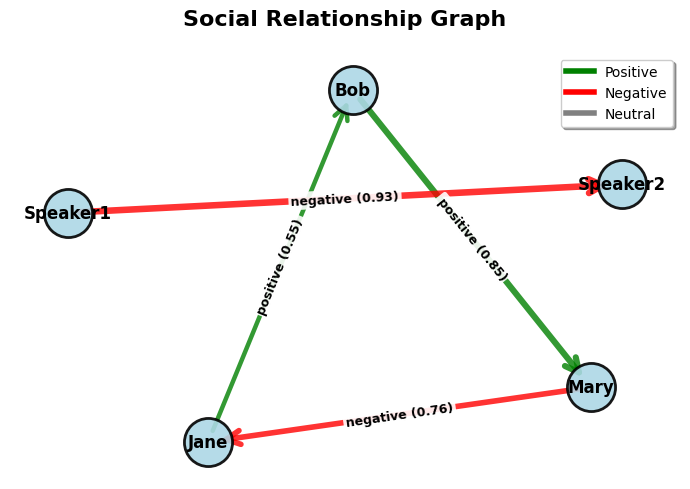

Saved graph image to /content/drive/MyDrive/My Research/Social_Graph_Mining/social_graph.png


In [24]:
links = []
for r in hybrid_results:
    s = {"source": str(r['source']),"target": str(r['target']),"linkType": str(r['linkType']),"strength": float(r['strength'])}
    links.append(s)

links_json = json.dumps(links, indent=2)
print("links JSON:\n", links_json)

with open('/content/drive/MyDrive/My Research/Social_Graph_Mining/links_output.json', 'w') as f:
    f.write(links_json)
print("Saved")
# Draw graph with straight arrows
G = nx.DiGraph()
for l in links:
    G.add_node(l['source'])
    G.add_node(l['target'])
    weight = l['strength']
    G.add_edge(l['source'], l['target'], weight=weight, sentiment=l['linkType'])

pos = nx.spring_layout(G, seed=42, k=3, iterations=50)
plt.figure(figsize=(7, 5))

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue',
                      edgecolors='black', linewidths=2, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

edge_colors = ['green' if G[u][v]['sentiment']=='positive' else 'red' if G[u][v]['sentiment']=='negative' else 'gray' for u,v in G.edges()]
edge_widths = [4 * G[u][v]['weight'] + 1 for u,v in G.edges()]

# Draw edges with STRAIGHT arrows
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                      arrowsize=25, arrowstyle='->',
                      connectionstyle="arc3,rad=0",  # STRAIGHT arrows (rad=0)
                      alpha=0.8)

edge_labels = {}
for u, v in G.edges():
    sentiment = G[u][v]['sentiment']
    weight = G[u][v]['weight']
    label = f"{sentiment} ({weight:.2f})"
    edge_labels[(u, v)] = label

# Draw edge labels along the edges
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9,
                           font_weight='bold',
                           bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='white',
                                   alpha=0.9,
                                   edgecolor='none'))

plt.axis('off')
plt.title("Social Relationship Graph", fontsize=16, fontweight='bold', pad=20)

# Add legend for sentiment colors
legend_elements = [plt.Line2D([0], [0], color='green', lw=4, label='Positive'),
                   plt.Line2D([0], [0], color='red', lw=4, label='Negative'),
                   plt.Line2D([0], [0], color='gray', lw=4, label='Neutral')]
plt.legend(handles=legend_elements, loc='upper right', frameon=True,
           fancybox=True, shadow=True)

out_png = '/content/drive/MyDrive/My Research/Social_Graph_Mining/social_graph.png'
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved graph image to", out_png)